In [12]:

import jax
import jax.numpy as jnp
from flax import nnx

from probjax.nn.nets.flows import AffineAutoregressiveFlow




In [27]:
p = AffineAutoregressiveFlow(4, 5, nnx.Rngs(1))

params = nnx.state(p, nnx.Param)

In [28]:
x1 = jax.random.normal(jax.random.PRNGKey(0), (1000, 4)) -2
x2 = jax.random.normal(jax.random.PRNGKey(1), (1000, 4)) +2

xs = jnp.concatenate([x1, x2], axis=0)  

In [29]:
def loss(params):
    nnx.update(p, params)
    return -jnp.mean(p.log_prob(xs))

In [30]:
import optax

optimizer = optax.adam(1e-3)

@jax.jit
def update(params, opt_state):
    loss_val, grads = jax.value_and_grad(loss)(params)
    updates, opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return loss_val, new_params, opt_state

In [31]:
opt_state = optimizer.init(params)

In [36]:
for i in range(1000):
    loss_val, params, opt_state = update(params, opt_state)
    print(loss_val)

6.359797
6.359287
6.359109
6.3588257
6.3586307
6.358418
6.35801
6.3577085
6.3574505
6.357304
6.356991
6.356743
6.3565073
6.356309
6.3561163
6.3558273
6.355733
6.3557386
6.355882
6.356356
6.357307
6.359031
6.3593507
6.358191
6.3558817
6.353634
6.3539333
6.3551645
6.3553452
6.3541784
6.3526945
6.3525586
6.3528557
6.35345
6.3531456
6.3520637
6.351384
6.3510885
6.351943
6.352051
6.351098
6.350225
6.350059
6.35055
6.3504934
6.3496866
6.3490176
6.3486533
6.3486104
6.348507
6.3482304
6.3480196
6.347686
6.3473663
6.3470674
6.346852
6.346727
6.3469076
6.3472757
6.3479605
6.3491435
6.3500047
6.3497486
6.348338
6.3460364
6.344721
6.3450384
6.345864
6.346134
6.3456244
6.3446913
6.343813
6.3432508
6.343144
6.3435802
6.343813
6.3437076
6.3433824
6.3428907
6.3422675
6.341736
6.341369
6.3419104
6.3424807
6.3419876
6.34131
6.340562
6.3400636
6.3404484
6.340561
6.340374
6.339986
6.3391304
6.338941
6.3387494
6.3386464
6.338682
6.338814
6.339425
6.3404956
6.341595
6.3421087
6.341428
6.3398275
6.3381114
6.

In [33]:
nnx.update(p, params)

In [34]:
samples = p.sample(jax.random.PRNGKey(0), (1000, ))

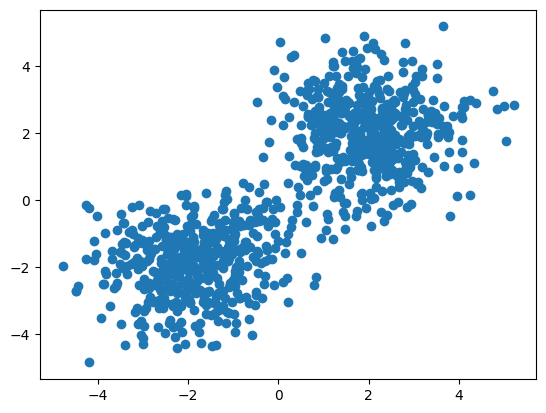

In [35]:
import matplotlib.pyplot as plt

plt.scatter(samples[:, 0], samples[:, 1])